# LogiSense — 06 | Executive Analytics & Decision Simulation

### Objective
Combine warehouse KPIs, OLAP comparisons and ML predictions into a decision-oriented notebook.

This is the notebook you can use to prepare screenshots for LinkedIn, viva and the Admin Dashboard.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

DATA=Path("../data/processed")
fact=pd.read_csv(DATA/"fact_delivery.csv")
dims={}
for n in ["dim_date","dim_customer","dim_product","dim_warehouse","dim_carrier","dim_shipping","dim_weather"]:
    p=DATA/f"{n}.csv"
    if p.exists(): dims[n]=pd.read_csv(p)

cube=fact.copy()
for n,t in dims.items():
    keys=[c for c in t.columns if c.endswith("_key")]
    if keys and keys[0] in cube.columns:
        cube=cube.merge(t,on=keys[0],how="left")
print(cube.shape)

(50000, 43)


## 1. Executive scorecard

The Admin dashboard should surface only KPIs that lead to a decision.

In [2]:
scorecard=pd.Series({
    "Orders":len(cube),
    "Revenue":cube["order_value_usd"].sum(),
    "Shipping Spend":cube["shipping_cost_usd"].sum(),
    "Avg Delivery Days":cube["actual_delivery_days"].mean(),
    "Avg Delay Days":cube["delivery_delay_days"].mean(),
    "Late Rate %":cube["late_flag"].mean()*100,
    "Return Rate %":cube["return_flag"].mean()*100,
    "Avg Rating":cube["customer_rating"].mean()
})
display(scorecard.round(2).to_frame("value"))

,value
Orders,50000.00
Revenue,8895855.33
Shipping Spend,6025776.91
Avg Delivery Days,8.35
Avg Delay Days,1.28
Late Rate %,56.32
Return Rate %,17.25
Avg Rating,3.37


## 2. Carrier comparison — reliability vs cost

A scatter plot is more informative than a ranking because it reveals trade-offs.

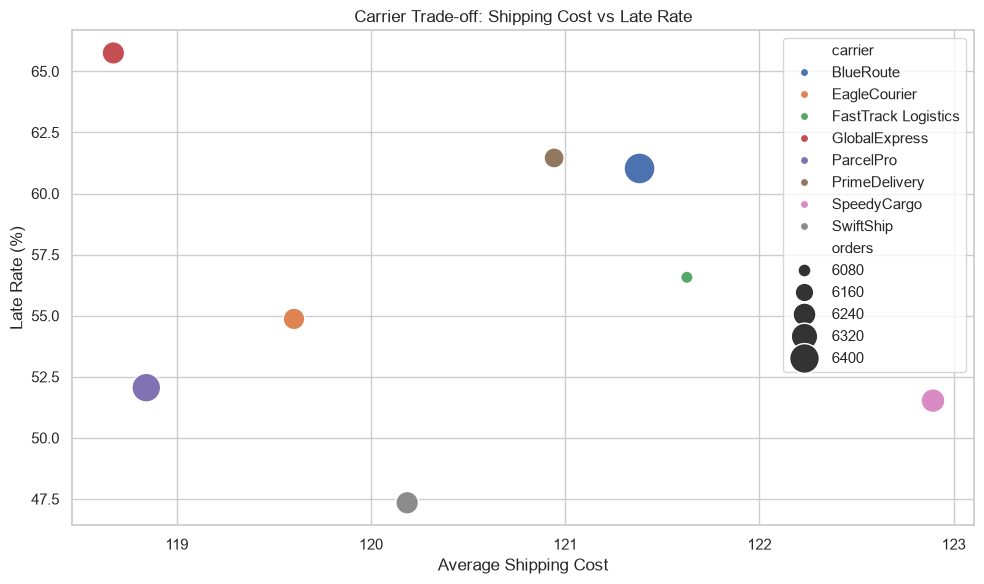

,carrier,orders,late_rate,avg_delay,avg_cost,rating
7,SwiftShip,6233,47.34,0.99,120.19,3.50
6,SpeedyCargo,6257,51.53,1.12,122.89,3.45
4,ParcelPro,6374,52.06,1.15,118.84,3.43
1,EagleCourier,6213,54.87,1.21,119.60,3.39
2,FastTrack Logistics,6072,56.57,1.26,121.63,3.37
0,BlueRoute,6435,61.03,1.43,121.38,3.30
5,PrimeDelivery,6185,61.46,1.47,120.94,3.29
3,GlobalExpress,6231,65.75,1.62,118.67,3.23


In [3]:
carrier=cube.groupby("carrier").agg(
    orders=("order_id","count"),
    late_rate=("late_flag","mean"),
    avg_delay=("delivery_delay_days","mean"),
    avg_cost=("shipping_cost_usd","mean"),
    rating=("customer_rating","mean")
).reset_index()
carrier["late_rate"]*=100

plt.figure(figsize=(10,6))
sns.scatterplot(data=carrier,x="avg_cost",y="late_rate",size="orders",hue="carrier",sizes=(80,500))
plt.title("Carrier Trade-off: Shipping Cost vs Late Rate")
plt.xlabel("Average Shipping Cost")
plt.ylabel("Late Rate (%)")
plt.tight_layout(); plt.show()

display(carrier.sort_values("late_rate").round(2))

## 3. Warehouse operational comparison

We compare processing time, delay and late rate. This helps distinguish a warehouse bottleneck from a downstream carrier issue.

In [4]:
wh=cube.groupby("warehouse_city").agg(
    orders=("order_id","count"),
    processing_hours=("warehouse_processing_hours","mean"),
    avg_delay=("delivery_delay_days","mean"),
    late_rate=("late_flag","mean"),
    shipping_cost=("shipping_cost_usd","mean")
).reset_index()
wh["late_rate"]*=100
display(wh.sort_values("late_rate",ascending=False).round(2))

,warehouse_city,orders,processing_hours,avg_delay,late_rate,shipping_cost
8,Sydney,3980,14.13,1.32,57.59,123.39
6,Paris,3990,14.50,1.31,57.12,122.02
3,London,4923,14.40,1.27,57.00,120.38
5,New York,7597,14.51,1.31,56.75,117.76
0,Berlin,4931,14.46,1.28,56.15,122.22
9,Toronto,4977,14.60,1.27,56.10,120.84
1,Chicago,5960,14.31,1.28,56.02,119.32
2,Dubai,3606,14.41,1.26,55.88,124.06
4,Los Angeles,7534,14.42,1.25,55.75,120.79
7,Singapore,2502,14.23,1.25,54.32,115.08


## 4. Shipping method comparison

Decision rule: do not choose the method with the lowest cost alone. Consider delay and customer experience together.

In [5]:
sm=cube.groupby("shipping_method").agg(
    orders=("order_id","count"),
    avg_delivery=("actual_delivery_days","mean"),
    avg_delay=("delivery_delay_days","mean"),
    late_rate=("late_flag","mean"),
    avg_cost=("shipping_cost_usd","mean"),
    rating=("customer_rating","mean")
).reset_index()
sm["late_rate"]*=100
display(sm.round(2))

,shipping_method,orders,avg_delivery,avg_delay,late_rate,avg_cost,rating
0,Economy,5577,10.56,1.50,61.70,48.91,3.28
1,Express,9696,3.61,0.62,43.41,107.58,3.57
2,International,15839,13.51,2.08,67.67,204.40,3.20
3,Same Day,1861,1.42,0.29,24.50,136.58,3.84
4,Standard,17027,6.28,0.96,54.84,71.55,3.40


## 5. Simple what-if scenario framework

For the website, this becomes a **Scenario Simulator**:
- choose carrier,
- choose shipping method,
- choose priority,
- enter distance/order value,
- estimate risk and delivery time.

The notebook demonstrates the decision concept; the website will call the saved ML models.

In [6]:
scenario_template = pd.DataFrame([{
    "customer_segment":"Consumer",
    "customer_country":"India",
    "customer_city":"Mumbai",
    "warehouse_id":cube["warehouse_id"].dropna().iloc[0] if "warehouse_id" in cube.columns else "",
    "warehouse_city":cube["warehouse_city"].dropna().iloc[0] if "warehouse_city" in cube.columns else "",
    "product_category":cube["product_category"].dropna().iloc[0] if "product_category" in cube.columns else "",
    "product_weight_kg":2.0,
    "order_value_usd":100.0,
    "shipping_method":cube["shipping_method"].dropna().iloc[0],
    "carrier":cube["carrier"].dropna().iloc[0],
    "distance_km":20.0,
    "promised_delivery_days":3.0,
    "package_size":cube["package_size"].dropna().iloc[0] if "package_size" in cube.columns else "",
    "payment_method":cube["payment_method"].dropna().iloc[0] if "payment_method" in cube.columns else "",
    "order_priority":cube["order_priority"].dropna().iloc[0] if "order_priority" in cube.columns else "",
    "weather_condition":cube["weather_condition"].dropna().iloc[0] if "weather_condition" in cube.columns else "",
    "delivery_attempts":1,
    "warehouse_processing_hours":4.0
}])
display(scenario_template)

,customer_segment,customer_country,customer_city,warehouse_id,warehouse_city,product_category,product_weight_kg,order_value_usd,shipping_method,carrier,distance_km,promised_delivery_days,package_size,payment_method,order_priority,weather_condition,delivery_attempts,warehouse_processing_hours
0,Consumer,India,Mumbai,WH-004,Toronto,Home & Kitchen,2.0,100.0,International,EagleCourier,20.0,3.0,Large,Digital Wallet,Normal,Snow,1,4.0


## 6. Final project architecture

```text
                    RAW CSV
                       |
                    ETL
                       |
              +--------+--------+
              |                 |
        STAR SCHEMA          DATA QUALITY
              |
       +------+------+
       |             |
   OLAP ENGINE      ML / MINING
       |             |
       +------+------+
              |
        LOGISENSE WEB APP
              |
     +--------+---------+
     |        |         |
  Admin   OLAP Explorer Risk / Simulator
 Dashboard  Filters     Predictions
```

### Portfolio positioning

> **LogiSense — E-commerce Logistics Intelligence Platform**  
> Built a Star-Schema data warehouse and interactive OLAP analytics layer, combined with machine-learning risk prediction, customer segmentation, association-rule mining and anomaly detection to support logistics decisions.

This is the story to use on LinkedIn and in your resume.